# From Pilot to Payoff - 05: Q4 - Business Payoff and Digital-Maturity Moderation

Q4: Is advanced adoption associated with business payoff, and does payoff differ by national digital maturity?


### Q4 - Business Payoff and Digital-Maturity Moderation

For Q4 we first compare business outcomes between adoption groups, then fit regressions with controls. Because the sample is so large, even a tiny difference comes out "significant", so we lean on the adjusted-R2 gains (how much each model actually explains) instead of the p-values.

## Setup and data preparation

Loads the data, builds the advanced-adoption flag and the digital-maturity tertile, and standardises the drivers used later.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats

from statsmodels.formula.api import ols

import matplotlib.pyplot as plt


In [2]:
company = pd.read_csv('ai_company_adoption.csv')
country_index = pd.read_csv('country_ai_index.csv')
print(f'company: {company.shape[0]:,} x {company.shape[1]}    country index: {country_index.shape[0]} x {country_index.shape[1]}')
company.head(3)


company: 150,000 x 43    country index: 30 x 8


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation


In [3]:
# Feature engineering: advanced-adoption target + national digital-maturity tertile (for the interaction).
company = company.copy()
company['advanced_adoption'] = company['ai_adoption_stage'].isin(['partial', 'full']).astype(int)

df = company.merge(country_index[['country', 'digital_maturity_index']], on='country', how='left')
df['digital_maturity_tertile'] = pd.qcut(df['digital_maturity_index'], q=3, labels=['Low', 'Medium', 'High'])
print(f'Data: {df.shape[0]:,} rows x {df.shape[1]:,} columns')


Data: 150,000 rows x 46 columns


In [4]:
# Standardise the firm-level drivers used in the M2 outcome models (per 1 SD).
standardise_cols = [
    'ai_training_hours', 'years_using_ai', 'ai_budget_percentage',
    'regulatory_compliance_score', 'ai_risk_management_score'
]
for col in standardise_cols:
    df[f'z_{col}'] = (df[col] - df[col].mean()) / df[col].std(ddof=0)

print('Created z-score variables for regression comparability.')


Created z-score variables for regression comparability.


In [5]:
stage_order = ['none', 'pilot', 'partial', 'full']


In [6]:
# Compare each business outcome across the four stages (Kruskal-Wallis) and advanced vs
# non-advanced (Mann-Whitney U). alpha = 0.05.
business_outcomes = {
    'productivity_change_percent': 'Productivity change (%)',
    'revenue_growth_percent': 'Revenue growth (%)',
    'cost_reduction_percent': 'Cost reduction (%)',
    'innovation_score': 'Innovation score',
    'customer_satisfaction': 'Customer satisfaction'
}

business_test_rows = []
for col, label in business_outcomes.items():
    stage_groups = [df.loc[df['ai_adoption_stage'] == stage, col].dropna() for stage in stage_order]
    h_stat, kw_p = stats.kruskal(*stage_groups)
    adv = df.loc[df['advanced_adoption'] == 1, col]
    nonadv = df.loc[df['advanced_adoption'] == 0, col]
    u_stat, mw_p = stats.mannwhitneyu(adv, nonadv, alternative='two-sided')
    business_test_rows.append({
        'outcome': label,
        'advanced_mean': adv.mean(),
        'non_advanced_mean': nonadv.mean(),
        'mean_difference': adv.mean() - nonadv.mean(),
        'kruskal_p_value': kw_p,
        'mann_whitney_p_value': mw_p
    })

business_tests = pd.DataFrame(business_test_rows)
business_tests


,outcome,advanced_mean,non_advanced_mean,mean_difference,kruskal_p_value,mann_whitney_p_value
0,Productivity change (%),12.189183,5.883665,6.305518,0.0,0.0
1,Revenue growth (%),6.240794,2.714272,3.526522,0.0,0.0
2,Cost reduction (%),5.829509,3.640198,2.189311,0.0,0.0
3,Innovation score,58.472995,51.410329,7.062666,0.0,0.0
4,Customer satisfaction,5.770525,5.015495,0.755031,0.0,0.0


In [7]:
# OLS outcome models. M0 controls only; M1 adds advanced adoption; M2 adds representative firm-level drivers.
ols_control_terms = 'C(country) + C(industry) + C(company_size) + C(survey_year) + C(quarter)'
representative_driver_terms = (
    'z_ai_training_hours + z_years_using_ai + z_ai_budget_percentage + '
    'z_regulatory_compliance_score + z_ai_risk_management_score'
)

business_ols_rows = []
business_ols_models = {}
for outcome, label in business_outcomes.items():
    m0 = ols(f'{outcome} ~ {ols_control_terms}', data=df).fit()
    m1 = ols(f'{outcome} ~ advanced_adoption + {ols_control_terms}', data=df).fit()
    m2 = ols(f'{outcome} ~ advanced_adoption + {representative_driver_terms} + {ols_control_terms}', data=df).fit()
    business_ols_models[outcome] = {'M0': m0, 'M1': m1, 'M2': m2}
    business_ols_rows.append({
        'outcome': label,
        'advanced_beta_M1': m1.params.get('advanced_adoption', np.nan),
        'p_value_M1': m1.pvalues.get('advanced_adoption', np.nan),
        'adj_R2_controls': m0.rsquared_adj,
        'adj_R2_plus_advanced': m1.rsquared_adj,
        'delta_adj_R2_advanced': m1.rsquared_adj - m0.rsquared_adj,
        'adj_R2_plus_drivers': m2.rsquared_adj,
        'delta_adj_R2_drivers': m2.rsquared_adj - m1.rsquared_adj
    })

business_ols_summary = pd.DataFrame(business_ols_rows)
business_ols_summary


,outcome,advanced_beta_M1,p_value_M1,adj_R2_controls,adj_R2_plus_advanced,delta_adj_R2_advanced,adj_R2_plus_drivers,delta_adj_R2_drivers
0,Productivity change (%),5.813068,0.0,0.101028,0.345503,0.244475,0.510352,0.164849
1,Revenue growth (%),3.284857,0.0,0.029415,0.117099,0.087684,0.161604,0.044505
2,Cost reduction (%),2.065253,0.0,0.026645,0.112315,0.085670,0.152173,0.039858
3,Innovation score,6.511190,0.0,0.052303,0.184283,0.131980,0.264757,0.080474
4,Customer satisfaction,0.702909,0.0,0.036968,0.140554,0.103586,0.207750,0.067196


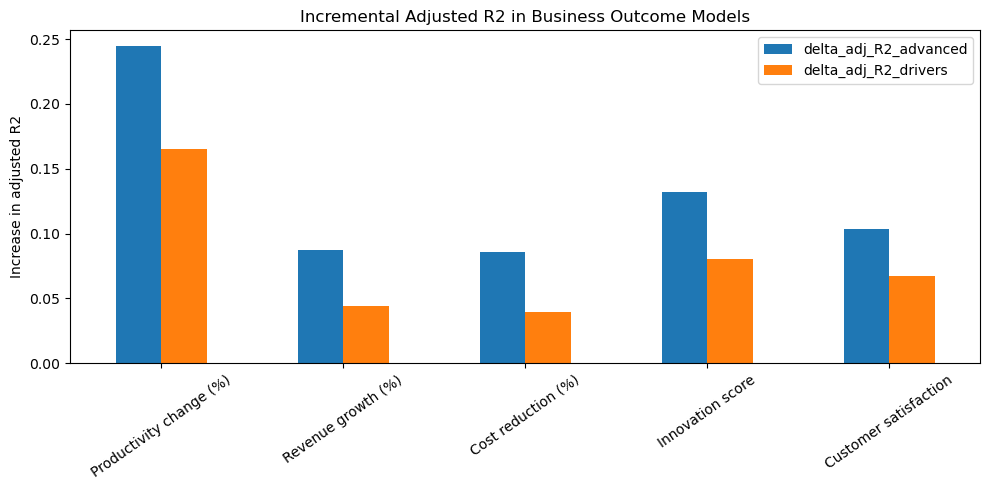

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = business_ols_summary.set_index('outcome')[['delta_adj_R2_advanced', 'delta_adj_R2_drivers']]
plot_data.plot(kind='bar', ax=ax)
ax.set_title('Incremental Adjusted R2 in Business Outcome Models')
ax.set_ylabel('Increase in adjusted R2')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()


In [9]:
# Does the payoff differ by national digital maturity? Add an advanced_adoption x maturity-tertile
# interaction. We drop the tertile's own main effect because it's constant within a country, so the
# C(country) controls already cover it.
interaction_outcomes = ['productivity_change_percent', 'revenue_growth_percent', 'cost_reduction_percent']
interaction_rows = []
for outcome in interaction_outcomes:
    formula = (f'{outcome} ~ advanced_adoption + '
               f'advanced_adoption:C(digital_maturity_tertile) + {ols_control_terms}')
    res = ols(formula, data=df).fit()
    for term in res.params.index:
        if term == 'advanced_adoption' or term.startswith('advanced_adoption:C(digital_maturity_tertile)'):
            interaction_rows.append({
                'outcome': outcome,
                'term': term,
                'coef': res.params[term],
                'p_value': res.pvalues[term],
                'adj_R2': res.rsquared_adj
            })

interaction_summary = pd.DataFrame(interaction_rows)
interaction_summary


,outcome,term,coef,p_value,adj_R2
0,productivity_change_percent,advanced_adoption,5.727258,0.000000,0.345527
1,productivity_change_percent,advanced_adoption:C(digital_maturity_tertile)[...,0.140414,0.013482,0.345527
2,productivity_change_percent,advanced_adoption:C(digital_maturity_tertile)[...,0.127902,0.028876,0.345527
3,revenue_growth_percent,advanced_adoption,3.248975,0.000000,0.117100
4,revenue_growth_percent,advanced_adoption:C(digital_maturity_tertile)[...,0.089507,0.150668,0.117100
5,revenue_growth_percent,advanced_adoption:C(digital_maturity_tertile)[...,0.019114,0.765708,0.117100
6,cost_reduction_percent,advanced_adoption,2.067916,0.000000,0.112306
7,cost_reduction_percent,advanced_adoption:C(digital_maturity_tertile)[...,-0.016488,0.678076,0.112306
8,cost_reduction_percent,advanced_adoption:C(digital_maturity_tertile)[...,0.009570,0.815045,0.112306


Advanced adopters perform better across all business outcomes, especially productivity. Their productivity is about 12%, compared with about 6% for others.

Since the dataset has 150,000 rows, most p-values are almost 0.0, so we focus more on adjusted R2. Adding advanced adoption improves productivity the most, with an adjusted R2 gain of about 0.24.

Country digital maturity does not seem to change the payoff much. The interaction effect is very small, only about 2% relative to the main productivity effect, and only borderline significant.

Overall, advanced adoption is linked to better outcomes, but this is still an association, not proof of causality.
